# Digital metamaterial inverse design — Stage 1 (2D pipeline validation)

ngl i think its best if we do the same way of AM FEM then make it into a bit map. design space is refractive index translated into bits (on certain threshold of ref index, it flips the bit into 1 as Si), target is the polarization rotation

Fork of [Autograd3InverseDesign.ipynb](Autograd3InverseDesign.ipynb) whose *only* change is the
**parameterization**: instead of a free-form continuous permittivity smoothed by a conic filter, the design
region is a **digital metamaterial** — a grid of square pixels that end up either air (`0`) or waveguide
material (`1`), exactly like the bit array in [hybrid_rotator_90.ipynb](hybrid_rotator_90.ipynb).

The physics in this notebook is deliberately left **untouched** from the reference: 2D, $\lambda = 1$,
$\varepsilon_{wg} = 2.75$, and the target is still the TE$_0 \rightarrow$ TE$_1$ mode converter.

> **Why not do the polarization rotator here?** A 2D simulation *cannot* rotate polarization. In 2D the TE and
> TM families decouple exactly, and even in 3D a structure that is mirror-symmetric about the horizontal
> midplane of the core has TE$_0$ and TM$_0$ in opposite parity classes of that mirror, so the conversion
> amplitude is identically zero for **every** bit pattern. Stage 1 therefore validates the digital pipeline
> cheaply in 2D; Stage 2 changes the design space, stack, and target.

**What Stage 1 must demonstrate**

1. Pixel size (*bit size*) and FDTD/permittivity resolution are **independent, tunable** knobs.
2. The optimizer converges while driving the pixels binary.
3. The final design survives **hard thresholding** to real bits (re-simulated, not assumed).
4. The bit array round-trips into `create_hybrid_rotator_90`'s ordering and into a single integer.

In [1]:
from typing import List

import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np

# import regular tidy3d
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad
from tidy3d.plugins.mode import ModeSolver

# set random seed to get same results
np.random.seed(2)

16:32:28 SE Asia Standard Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\James\.config\tidy3d'. Found legacy 
                               directory at 'C:\Users\James\.tidy3d', which will
                               be ignored. Tidy3D configuration now uses        
                               'C:\Users\James\.config\tidy3d\config.toml'.     

## Parameters

Unchanged from the reference, except for the design-region discretization in the cell after this one.

In [2]:
# wavelength and frequency
wavelength = 1.0
freq0 = td.C_0 / wavelength
k0 = 2 * np.pi * freq0 / td.C_0

# space between boxes and PML
buffer = 1.0 * wavelength

# optimize region size
lz = td.inf
lx = 5.0
ly = 3.0

# position of source and monitor (constant for all)
source_x = -lx / 2 - buffer * 0.8
meas_x = lx / 2 + buffer * 0.8

# total size
Lx = lx + 2 * buffer
Ly = ly + 2 * buffer
Lz = 0.0

# permittivity and width of the input/output waveguide
eps_wg = 2.75
wg_width = 0.7

# frequency width and run time
freqw = freq0 / 10
run_time = 50 / freqw

### The two resolution knobs

This is the core change. The reference notebook sets `dl_design_region = 0.01` and defines **one parameter per
FDTD cell**, giving $500 \times 300 = 150{,}000$ free parameters — a free-form design, not a digital one.

A digital metamaterial needs the opposite: few, coarse parameters. But the pixel pitch we want (0.1 µm) is far
too coarse to *simulate* on — at $\lambda / n = 1.0 / 1.66 = 0.60$ µm that would be only 6 cells per wavelength.

So the two are separated:

| knob | meaning |
|---|---|
| `pixel_size` | *bit size*: edge length of one pixel, and the layout's minimum feature |
| `dl_eps` | *resolution*: permittivity-array and design-region FDTD step |

They are linked by an **integer** ratio `k = pixel_size / dl_eps`. Optimization happens on the coarse bit grid;
each bit is expanded into a $k \times k$ block of permittivity cells before it reaches the solver. Both are free
to tune — change either and everything downstream follows.

In [3]:
# --- the two independent knobs -------------------------------------------------
pixel_size = 0.1      # "bit size": edge length of one metamaterial pixel (um)
dl_eps = 0.02         # permittivity-array / design-region FDTD resolution (um)
# -------------------------------------------------------------------------------

k = int(round(pixel_size / dl_eps))
assert abs(pixel_size / dl_eps - k) < 1e-9, "pixel_size must be an integer multiple of dl_eps"

# bit grid: the optimization variables
n_bx = int(round(lx / pixel_size))
n_by = int(round(ly / pixel_size))
n_bits = n_bx * n_by

# permittivity grid: what the solver actually sees
nx, ny = n_bx * k, n_by * k
dl_design_region = dl_eps

# random starting parameters between 0 and 1, one per PIXEL (not per FDTD cell)
rng = np.random.default_rng(0)
params0 = rng.random((n_bx, n_by))

# a binary random start, matching hybrid_rotator_90's `random_pattern`, is also valid:
# params0 = rng.integers(0, 2, (n_bx, n_by)).astype(float) * 0.98 + 0.01

print(f"pixel size {pixel_size} um  ->  bit grid {n_bx} x {n_by} = {n_bits} bits")
print(f"eps resolution {dl_eps} um  ->  eps grid {nx} x {ny} ({k}x{k} cells per pixel)")
print(f"cells per wavelength in the guide: {wavelength / np.sqrt(eps_wg) / dl_eps:.1f}")
print(f"reference notebook, for comparison: {int(lx / 0.01) * int(ly / 0.01)} free parameters")

pixel size 0.1 um  ->  bit grid 50 x 30 = 1500 bits
eps resolution 0.02 um  ->  eps grid 250 x 150 (5x5 cells per pixel)
cells per wavelength in the guide: 30.2
reference notebook, for comparison: 150000 free parameters


### Static components

Verbatim from the reference: the input/output waveguide, and the source/measurement planes.

In [4]:
waveguide = td.Structure(
    geometry=td.Box(size=(2 * Lx, wg_width, lz)), medium=td.Medium(permittivity=eps_wg)
)

mode_size = (0, wg_width * 3, lz)

source_plane = td.Box(
    center=[source_x, 0, 0],
    size=mode_size,
)

measure_plane = td.Box(
    center=[meas_x, 0, 0],
    size=mode_size,
)

## Digital metamaterial parameterization

The reference builds its permittivity with a conic filter followed by a tanh projection:

```python
filter_project = make_filter_and_project(radius, lx / nx)   # radius = 0.120
```

**Both the filter and the erosion/dilation penalty are dropped here**, deliberately. Their job is to impose a
minimum feature size on a free-form design. On a pixel grid the pixel *is* the minimum feature size, so the
filter is redundant — and worse, with `radius = 0.120 > pixel_size = 0.1` it would blur neighbouring pixels
into each other and actively fight the binarization we want.

What is left is the piece that does the real work:

- `tanh_projection(params, beta)` pushes each pixel toward 0 or 1. $\beta$ is ramped up during optimization so
  the design starts continuous (informative gradients) and ends binary (manufacturable).
- `upsample` expands each pixel into a $k \times k$ block. It is a Kronecker product with a block of ones, so
  it is differentiable: autograd's reverse pass simply **sums** the sub-cell gradients back onto each pixel.

In [5]:
from tidy3d.plugins.autograd import rescale, tanh_projection


def get_density(params, beta):
    """(n_bx, n_by) params in [0, 1] -> binarized pixel density, same shape."""
    return tanh_projection(params, beta=beta, eta=0.5)


def upsample(density, k):
    """Expand each pixel into a k x k block of permittivity cells. Differentiable."""
    return anp.kron(density, anp.ones((k, k)))


def get_eps(params, beta):
    """(n_bx, n_by) params -> (nx, ny) permittivity in [1, eps_wg]."""
    return rescale(upsample(get_density(params, beta), k), 1, eps_wg)


def make_input_structures(params, beta) -> List[td.Structure]:
    box = td.Box(center=(0, 0, 0), size=(lx, ly, lz))
    eps_data = get_eps(params, beta=beta).reshape((nx, ny, 1))
    custom_structure = td.Structure.from_permittivity_array(geometry=box, eps_data=eps_data)

    return [custom_structure]

Check that the two grids line up and that a pixel really is one solid block.

eps array shape: (250, 150)   expected: (250, 150)
eps range: 1.000 .. 2.750  (1 = air, eps_wg = waveguide)
max spread within a pixel: 0.0


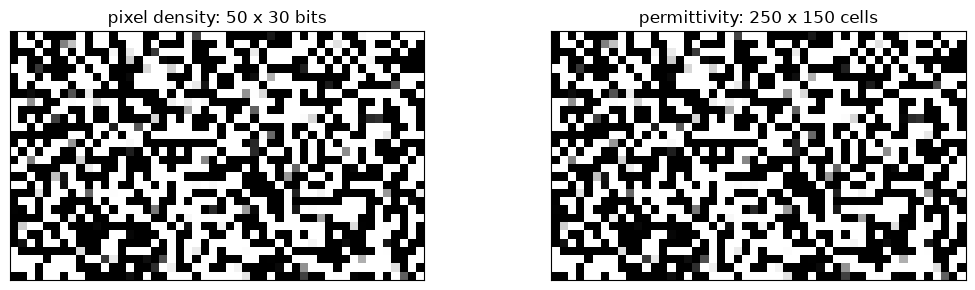

In [6]:
eps_check = get_eps(params0, beta=50.0)
print("eps array shape:", eps_check.shape, "  expected:", (nx, ny))
print("eps range:", f"{eps_check.min():.3f} .. {eps_check.max():.3f}", " (1 = air, eps_wg = waveguide)")

# every k x k block must be uniform -- that is what makes the design "digital"
blocks = eps_check.reshape(n_bx, k, n_by, k)
print("max spread within a pixel:", np.abs(blocks - blocks[:, :1, :, :1]).max())

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 3), tight_layout=True)
a0.imshow(np.flipud(get_density(params0, beta=50.0).T), cmap="gray_r", interpolation="nearest")
a0.set_title(f"pixel density: {n_bx} x {n_by} bits")
a1.imshow(np.flipud(eps_check.T), cmap="gray_r", interpolation="nearest")
a1.set_title(f"permittivity: {nx} x {ny} cells")
for a in (a0, a1):
    a.set_xticks([])
    a.set_yticks([])
plt.show()

### Bit-array helpers

`number_to_bits` and `bits_to_number` are copied unchanged from
[hybrid_rotator_90.ipynb](hybrid_rotator_90.ipynb) so a finished design can be stored as a single integer.

`to_bitstring` is the bridge to `create_hybrid_rotator_90`, and it is the one place where an off-by-one is easy
and silent. That function loops

```python
for i in range(int(rot_width / wg_resolution)):        # i indexes y, DESCENDING from +width/2
    for j in range(int(rot_length / wg_resolution)):   # j indexes x, ascending
```

so its flat array is row-major with **y running downward**. Tidy3D's permittivity array is indexed
`[ix, iy]` with **y running upward**. Hence the flip before the transpose. The cell after next checks this
against a literal replay of that loop rather than trusting the reasoning.

In [7]:
# --- copied verbatim from hybrid_rotator_90.ipynb ---
def number_to_bits(n: int, num_bits: int) -> np.ndarray:
    bit_string = format(n, f"0{num_bits}b")  # MSB-first, zero-padded to num_bits
    return np.array(list(bit_string), dtype=np.uint8)


def bits_to_number(bits: np.ndarray) -> int:
    bit_string = "".join(bits.astype(str))
    return int(bit_string, 2)


# --- bridge from the autograd grid to create_hybrid_rotator_90's flat ordering ---
def to_bitstring(bits_2d: np.ndarray) -> np.ndarray:
    """(n_bx, n_by) indexed [x asc, y asc] -> flat (n_bits,) in create_hybrid_rotator_90 order."""
    return np.flip(bits_2d, axis=1).T.ravel().astype(np.uint8)


def from_bitstring(flat: np.ndarray, n_bx: int, n_by: int) -> np.ndarray:
    """Inverse of to_bitstring."""
    return np.flip(np.asarray(flat).reshape(n_by, n_bx).T, axis=1)

In [8]:
# Verify to_bitstring by replaying create_hybrid_rotator_90's own loop: for each flat index it
# computes the pixel centre (x, y) that function would place, then asks which (ix, iy) of our
# grid that centre falls in, and compares the bit values.
probe = rng.integers(0, 2, (n_bx, n_by)).astype(np.uint8)
flat = to_bitstring(probe)

ok = True
n = 0
for i in range(n_by):
    for j in range(n_bx):
        x = j * pixel_size + pixel_size / 2 - lx / 2
        y = ly / 2 - pixel_size / 2 - i * pixel_size
        ix = int(round((x + lx / 2 - pixel_size / 2) / pixel_size))
        iy = int(round((y + ly / 2 - pixel_size / 2) / pixel_size))
        ok &= bool(flat[n] == probe[ix, iy])
        n += 1

print("to_bitstring matches create_hybrid_rotator_90 ordering:", ok)
print("from_bitstring inverts to_bitstring:", np.array_equal(from_bitstring(flat, n_bx, n_by), probe))
print("integer round-trip lossless:", np.array_equal(number_to_bits(bits_to_number(flat), n_bits), flat))
assert ok, "bit ordering mismatch"

to_bitstring matches create_hybrid_rotator_90 ordering: True
from_bitstring inverts to_bitstring: True
integer round-trip lossless: True


### Making the simulation

Verbatim from the reference. `dl_design_region` now carries `dl_eps` rather than the parameter pitch, which is
the only reason this cell behaves differently.

In [9]:
def make_sim_base(params: np.ndarray, beta: float) -> td.Simulation:
    """Create the simulation given the parameters and some beta value."""

    structures = make_input_structures(params, beta=beta)
    design_region_mesh = td.MeshOverrideStructure(
        geometry=td.Box(size=(lx, ly, lz)),
        dl=[dl_design_region] * 3,
        enforce=True,
    )
    grid_spec = td.GridSpec.auto(
        wavelength=wavelength,
        min_steps_per_wvl=16,
        override_structures=[design_region_mesh],
    )

    return td.Simulation(
        size=[Lx, Ly, Lz],
        grid_spec=grid_spec,
        structures=[waveguide] + structures,
        sources=[],
        monitors=[],
        run_time=run_time,
        boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=False),
    )

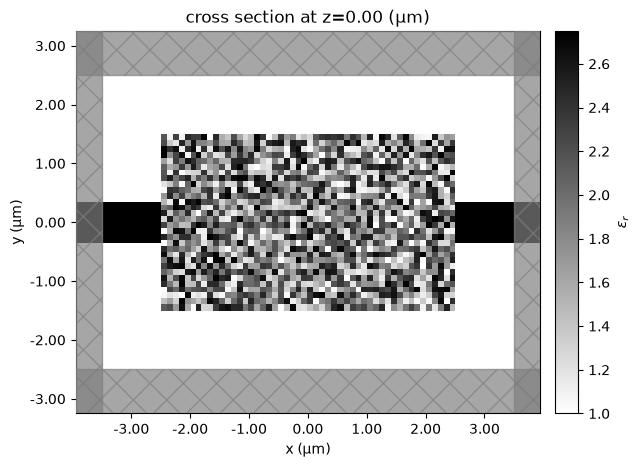

In [10]:
sim_start = make_sim_base(params0, beta=1.0)

ax = sim_start.plot_eps(z=0, freq=freq0)

plt.show()

### Select input and output modes

Unchanged from the reference. We inject the fundamental Ez-polarized mode and target the 1st order
Ez-polarized mode, i.e. `mode_index=0` and `mode_index=2`.

In [11]:
from tidy3d.plugins.mode.web import run as run_mode_solver

num_modes = 4
mode_spec = td.ModeSpec(num_modes=num_modes)

mode_solver = ModeSolver(
    simulation=sim_start,
    plane=source_plane,
    mode_spec=td.ModeSpec(num_modes=num_modes),
    freqs=[freq0],
)
modes = run_mode_solver(mode_solver, reduce_simulation=True)

16:33:04 SE Asia Standard Time Mode solver created with                         
                               task_id='fdve-c5e7039f-af63-443b-a03d-44c7d7bbda4
                               d',                                              
                               solver_id='mo-c65963c2-8778-426e-ac56-a9620dae00d
                               e'.

Output()

Output()

16:33:10 SE Asia Standard Time Mode solver status: success

Output()

Effective index of computed modes:  [[1.57199487 1.53558055 1.30320163 1.18556448]]


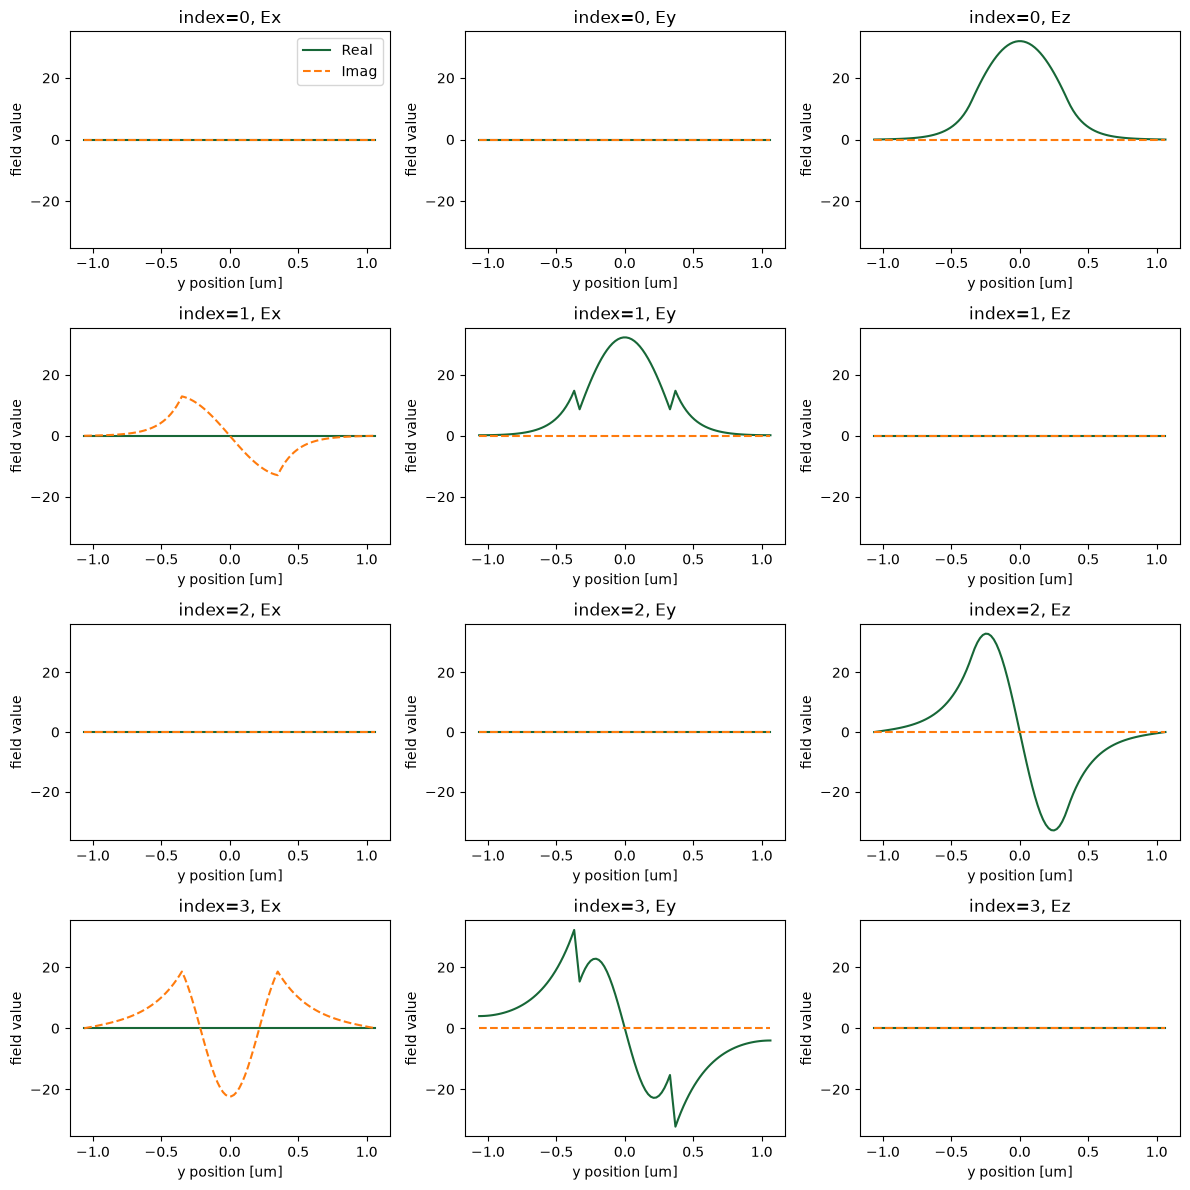

In [12]:
fig, axs = plt.subplots(num_modes, 3, figsize=(12, 12), tight_layout=True)
for mode_index in range(num_modes):
    vmax = 1.1 * max(
        abs(modes.field_components[n].sel(mode_index=mode_index)).max() for n in ("Ex", "Ey", "Ez")
    )
    for field_name, ax in zip(("Ex", "Ey", "Ez"), axs[mode_index]):
        field = modes.field_components[field_name].sel(mode_index=mode_index)
        field.real.plot(label="Real", ax=ax)
        field.imag.plot(ls="--", label="Imag", ax=ax)
        ax.set_title(f"index={mode_index}, {field_name}")
        ax.set_ylim(-vmax, vmax)

axs[0, 0].legend()

print("Effective index of computed modes: ", np.array(modes.n_eff))

In [13]:
mode_index_in = 0
mode_index_out = 2

num_modes = max(mode_index_in, mode_index_out) + 1

mode_spec = td.ModeSpec(num_modes=num_modes)

In [14]:
# source seeding the simulation
forward_source = td.ModeSource(
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freqw),
    center=[source_x, 0, 0],
    size=mode_size,
    mode_index=mode_index_in,
    mode_spec=mode_spec,
    direction="+",
)

# we'll refer to the measurement monitor by this name often
measurement_monitor_name = "measurement"

# monitor where we compute the objective function from
measurement_monitor = td.ModeMonitor(
    center=[meas_x, 0, 0],
    size=mode_size,
    freqs=[freq0],
    mode_spec=mode_spec,
    name=measurement_monitor_name,
)

In [15]:
def make_sim(params, beta):
    sim = make_sim_base(params, beta=beta)
    return sim.updated_copy(sources=[forward_source], monitors=[measurement_monitor])

### Objective function

`measure_power` is unchanged. `J` loses the erosion/dilation penalty term for the reason given above — the
pixel grid already guarantees the minimum feature size, so the objective is simply the converted power.

In [16]:
def measure_power(sim_data: td.SimulationData) -> float:
    """Return the power in the output_data amplitude at the mode index of interest."""
    output_amps = sim_data["measurement"].amps
    amp = output_amps.sel(direction="+", f=freq0, mode_index=mode_index_out).values
    return anp.sum(anp.abs(amp) ** 2)


def J(params: np.ndarray, beta: float, step_num: int = None, verbose: bool = False) -> float:
    sim = make_sim(params, beta=beta)
    task_name = "invdes_digital"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    return measure_power(sim_data)

Sanity-check one forward+backward pass. The gradient must come back on the **bit grid** `(n_bx, n_by)`, not on
the permittivity grid — that is the proof that the upsample's adjoint is folding the sub-cell sensitivities
back onto each pixel.

In [17]:
dJ_fn = value_and_grad(J)

In [18]:
val, grad = dJ_fn(params0, beta=1, verbose=True)

print(f"J = {val:.4e}")
print(f"gradient shape  = {grad.shape}   (bit grid = {(n_bx, n_by)}, eps grid = {(nx, ny)})")
print(f"gradient norm   = {np.linalg.norm(grad):.4e}")
assert grad.shape == (n_bx, n_by), "gradient is not on the bit grid"
assert np.linalg.norm(grad) > 0, "gradient vanished"

16:34:25 SE Asia Standard Time Created task 'invdes_digital' with resource_id   
                               'fdve-2f98f86c-2782-4737-9030-561a146ab6ca' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=12603855;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2f98f86c-2782-4737-9030-561a146ab6ca\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=12603856;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2f98f86c-2782-4737-9030-561a146ab6ca\taskId]8;;\
                               ]8;id=12603855;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2f98f86c-2782-4737-9030-561a146ab6ca\=]8;;\]8;id=12603857;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2f98f86c-2782-4737-9030-561a146ab6ca\fdve]8;;\]8;id=12603855;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2f98f86c-2782-4737-9030-561a146ab6ca\-2f98f86c-2782-4737-9030-561a146ab6ca']8;;\.

                               Task folder: ]8;id=12603860;https://tidy3d.simulation.cloud/folders/folder-0115173b-c38d-46ac-ae26-956a6110dbd7\'default']8;;\.

Output()

Output()

...

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after completion.

Output()

16:35:48 SE Asia Standard Time Batch complete.

Output()

J = 4.1395e-03
gradient shape  = (50, 30)   (bit grid = (50, 30), eps grid = (250, 150))
gradient norm   = 4.0294e-02


## Optimization

Adam, as in the reference. Two changes:

- **$\beta$ ramps to 80, not 20.** The reference stops at $\beta = 20$, which leaves visibly grey pixels. A
  digital metamaterial has to end genuinely binary, otherwise thresholding at the end throws away performance.
- **The preview is drawn after $\beta$ is assigned.** In the reference the `imshow` call sits *above* the
  `beta = ...` line, so on the first iteration it silently re-uses the stale module-level `beta = 50` left over
  from the filter cell. Harmless, but confusing to read.

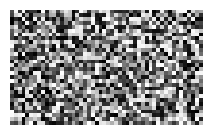

step = 1
	beta = 2.0000e+00
	J = 5.1491e-03
	grad_norm = 4.6935e-02


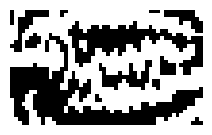

step = 2
	beta = 6.0000e+00
	J = 4.6489e-03
	grad_norm = 0.0000e+00


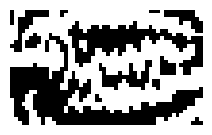

step = 3
	beta = 1.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


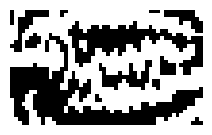

step = 4
	beta = 1.4000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


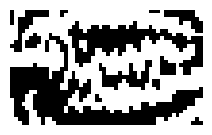

step = 5
	beta = 1.8000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


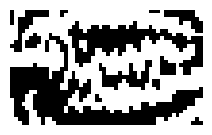

step = 6
	beta = 2.2000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


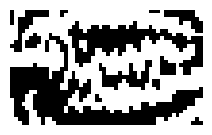

step = 7
	beta = 2.6000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


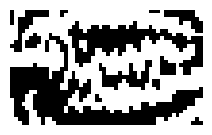

step = 8
	beta = 3.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


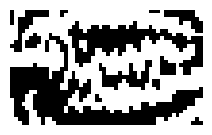

step = 9
	beta = 3.4000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


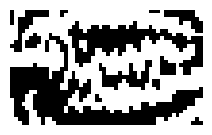

step = 10
	beta = 3.8000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


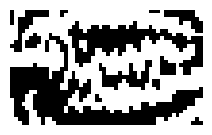

step = 11
	beta = 4.2000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


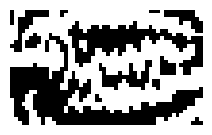

step = 12
	beta = 4.6000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


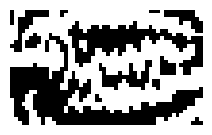

step = 13
	beta = 5.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


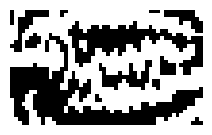

step = 14
	beta = 5.4000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


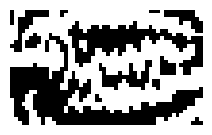

step = 15
	beta = 5.8000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


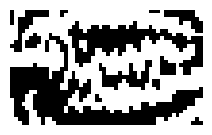

step = 16
	beta = 6.2000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


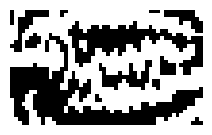

step = 17
	beta = 6.6000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


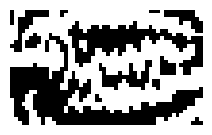

step = 18
	beta = 7.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


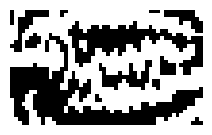

step = 19
	beta = 7.4000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


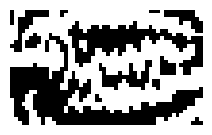

step = 20
	beta = 7.8000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


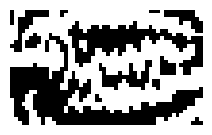

step = 21
	beta = 8.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


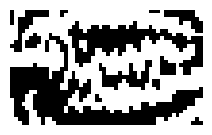

step = 22
	beta = 8.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


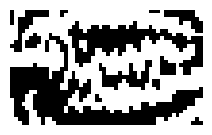

step = 23
	beta = 8.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


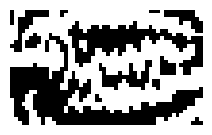

step = 24
	beta = 8.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


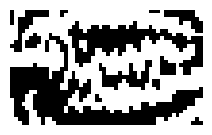

step = 25
	beta = 8.0000e+01
	J = 4.6489e-03
	grad_norm = 0.0000e+00


In [19]:
from tidy3d.plugins.autograd import adam, apply_updates

# hyperparameters
num_steps = 25
learning_rate = 1.0

# initialize adam optimizer with starting parameters
params = np.array(params0)
optimizer = adam(learning_rate=learning_rate)
opt_state = optimizer.init(params)

# store history
Js = []
params_history = [params.copy()]
beta_history = []

# gradually increase the binarization strength
beta0 = 2
beta_increment = 4
beta_max = 80

for i in range(num_steps):
    beta = min(beta0 + i * beta_increment, beta_max)

    # preview the current design (drawn AFTER beta is set, unlike the reference)
    density = get_density(params, beta)
    plt.subplots(figsize=(2.5, 1.5))
    plt.imshow(np.flipud(1 - density.T), cmap="gray", interpolation="nearest")
    plt.axis("off")
    plt.show()

    # compute gradient and current objective function value
    value, gradient = dJ_fn(params, step_num=i + 1, beta=beta)

    # outputs
    print(f"step = {i + 1}")
    print(f"\tbeta = {beta:.4e}")
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # compute and apply updates to the optimizer based on gradient (-1 sign to maximize obj_fn)
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params[:] = apply_updates(params, updates)

    # cap the parameters
    anp.clip(params, 0.0, 1.0, out=params)

    # save history
    Js.append(value)
    params_history.append(params.copy())
    beta_history.append(beta)

params_final = params_history[-1]

### Results

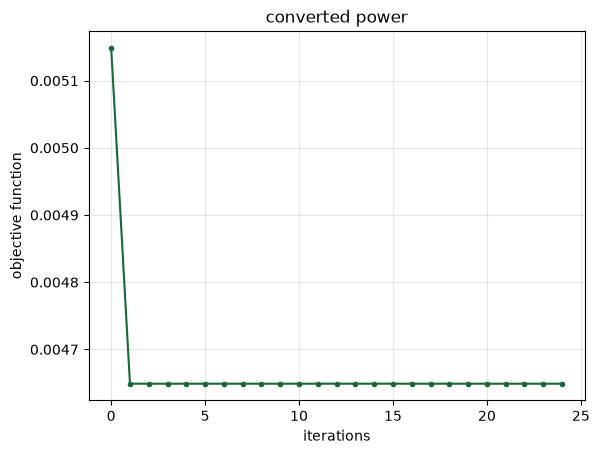

In [20]:
plt.plot(Js, marker="o", ms=3)
plt.xlabel("iterations")
plt.ylabel("objective function")
plt.title("converted power")
plt.grid(alpha=0.3)
plt.show()

## Binarization: from a relaxed design to real bits

The optimizer works on a *relaxed* problem — pixels are free to sit anywhere in $[0, 1]$. A manufacturable
device needs each pixel to be exactly air or exactly waveguide, so the design is hard-thresholded at 0.5.

That threshold is a real perturbation, and the honest way to score it is to **re-simulate**. The relaxed
objective from the loop above is *not* the device's performance; the number printed for the thresholded design
is. If the drop is large, the fix is a longer or steeper $\beta$ ramp — not quoting the relaxed number.

In [ ]:
density_final = get_density(params_final, beta=beta)
bits_2d = (density_final > 0.5).astype(np.uint8)

grey = np.mean((density_final >= 0.05) & (density_final <= 0.95))
print(f"pixels still grey after the beta ramp: {grey * 100:.2f}%")
print(f"waveguide-material fill fraction: {bits_2d.mean() * 100:.1f}%")

# beta -> inf reproduces the bits exactly, so this evaluates the thresholded device
J_relaxed = Js[-1]
J_binary = J(bits_2d.astype(float), beta=1e6, verbose=False)

print(f"\nrelaxed J (from the loop)   = {J_relaxed:.4f}")
print(f"hard-binarized J (re-run)   = {J_binary:.4f}   <-- the number that counts")
print(f"loss from thresholding      = {(J_relaxed - J_binary) * 100:.2f} percentage points")

In [ ]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 3), tight_layout=True)
a0.imshow(np.flipud(1 - density_final.T), cmap="gray", interpolation="nearest")
a0.set_title(f"relaxed density (beta = {beta})")
a1.imshow(np.flipud(1 - bits_2d.T), cmap="gray", interpolation="nearest")
a1.set_title("hard bits")
for a in (a0, a1):
    a.set_xticks([])
    a.set_yticks([])
plt.show()

### Export the bit array

The flat array below is in `create_hybrid_rotator_90`'s ordering, so it can be dropped straight into
[hybrid_rotator_90.ipynb](hybrid_rotator_90.ipynb) once Stage 2 has produced a design on the real
5.0 × 1.5 µm footprint.

In [ ]:
bits_flat = to_bitstring(bits_2d)
design_number = bits_to_number(bits_flat)

print(f"{n_bits} bits, first 20: {bits_flat[:20]}")
print(f"round-trips through the integer: {np.array_equal(number_to_bits(design_number, n_bits), bits_flat)}")
print(f"round-trips back to the 2D grid: {np.array_equal(from_bitstring(bits_flat, n_bx, n_by), bits_2d)}")
print(f"\ndesign as a single integer:\n{design_number}")

np.save("digital_metamaterial_stage1_bits.npy", bits_flat)

### Final fields

One last run of the **thresholded** device with a field monitor attached, to confirm it behaves the way the
objective claims.

In [ ]:
field_mnt = td.FieldMonitor(
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="field_mnt",
)

sim_final = make_sim(bits_2d.astype(float), beta=1e6)
sim_final = sim_final.copy(update=dict(monitors=(field_mnt, measurement_monitor)))

sim_data_final = web.run(sim_final, task_name="invdes_digital_final")

In [ ]:
f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3), tight_layout=True)
sim_final.plot_eps(z=0.01, freq=freq0, ax=ax0)
ax1 = sim_data_final.plot_field("field_mnt", "Ez", z=0, ax=ax1)
ax2 = sim_data_final.plot_field("field_mnt", "E", "abs^2", z=0, ax=ax2)
plt.show()

final_power = (
    sim_data_final["measurement"].amps.sel(direction="+", f=freq0, mode_index=mode_index_out).abs ** 2
)
print(f"Final power conversion (thresholded device) = {float(final_power) * 100:.2f}%")

## Next: Stage 2 — TE→TM polarization rotator

With the pipeline validated, Stage 2 changes the design space, parameters, and target. Every parameterization
cell above carries over unchanged; what moves is the physics.

| item | Stage 1 (this notebook) | Stage 2 (TE→TM rotator) |
|---|---|---|
| wavelength | 1.0 | 1.55 (optimize at `freq0`; sweep 1.53–1.57 at the end) |
| dimensionality | `lz=td.inf`, `Lz=0.0`, `pml(z=False)` | `lz=0.22`, `Lz=0.22+2*buffer_z`, `pml(x, y, z=True)` |
| design region | box at `z=0` | `td.Box(center=(0,0,0.11), size=(lx,ly,0.22))`, `eps_data` shape `(nx,ny,1)` — uniform in z, i.e. a real lithographic pattern |
| stack | none | SiO₂ below `z=0`, **air above**, `eps_wg = 3.475**2 = 12.076` |
| footprint | 5.0 × 3.0 | 5.0 × 1.5 → 50 × 15 = 750 bits at 0.1 µm |
| waveguide | `wg_width = 0.7` | `wg_width = 0.5` |
| target | `mode_index_out = 2` | TM₀ — **resolve via `te_fraction`, do not hardcode** |
| symmetry | — | **none**; y or z symmetry forces the conversion to zero |

Two things Stage 2 must not skip:

1. **Air cladding is mandatory.** In SiEPIC `ebeam`, an undrawn pixel is SiO₂ (ε = 2.087), *not* air, and the
   silicon is capped by oxide too — leaving the core mirror-symmetric about z = 0.11 µm, where TE₀ and TM₀ sit
   in opposite parity classes and cannot couple **at all**. Drawing the design region on the
   `"Oxide open to BOX"` (6,0) layer replaces the oxide above z = 0 with air and breaks that symmetry. Verify
   with a permittivity probe before optimizing anything.
2. **The output mode index must be discovered, not assumed.** For a 500 × 220 nm silicon wire expect
   TE₀ ≈ 2.44 and TM₀ ≈ 1.77, so TM₀ is *probably* index 1 — but run the mode solver with `num_modes=4` and
   select on `te_fraction`. This also settles the open question in `hybrid_rotator_90.ipynb`
   ("make sure ini ga kebalik TE-TM nya").

Cost note: Stage 2 is 3D, and autograd runs **two** simulations per step (forward + adjoint). Run `J` once with
`verbose=True` and check `web.estimate_cost` before committing to the full loop.